<a href="https://colab.research.google.com/github/JeongDell/Like-Lion-NLP-4th/blob/main/Tokenize_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
df = pd.read_csv(url, delimiter='\t')
df.head()

# Save the DataFrame to an Excel file
#df.to_excel('output.xlsx', index=False)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


In [ ]:
count = len(df)
print(f"총 데이터 개수: {count}개")

총 데이터 개수: 150000개


다음 `MeCab` 라이브러리는 한국어에 맞춰 만들어진 형태소 분석기입니다.  
아래 사용 방법을 참고하여 단어를 토큰으로 만들고 단어사전을 구축하십시오.

## MeCab 설치

In [ ]:
!pip install -q python-mecab-ko

In [ ]:
from mecab import MeCab
mecab = MeCab()
morphs = mecab.morphs

In [ ]:
sample = df['document'][0]
sample_token = morphs(sample)
print(sample_token)

['아', '더', '빙', '.', '.', '진짜', '짜증', '나', '네요', '목소리']


## Q1. 위 데이터는 정제되지 않은 raw 데이터입니다. 적절한 전처리 작업을 수행하십시오.

In [ ]:
import re

def preprocessor(text):
    if pd.isnull(text):
        return ""

    # Ensure the input is treated as a string
    text = str(text)

    # 1. 문장기호 제거 (Remove punctuation and special characters)
    # 한글, 숫자, 공백을 제외한 모든 문자(구두점, 특수문자 등)를 제거합니다.
    text = re.sub(r'[^가-힣0-9\s]', '', text)

    # 2. 맞춤법 검사 후 수정 (Spell check and correction)
    # 한국어 맞춤법 검사는 복잡하며, 전문 라이브러리(예: hanspell, pykospacing)
    # 또는 학습된 모델이 필요합니다. 여기서는 직접 구현하지 않습니다.
    # 필요시 추가적인 라이브러리를 설치하고 통합해야 합니다.

    # 3. 다른 전처리 (Other preprocessing steps)
    # 여러 개의 공백을 하나의 공백으로 줄이고, 문장 양 끝의 공백을 제거합니다.
    text = re.sub(r'\s+', ' ', text).strip()

    # (선택 사항) 숫자를 제거하려면 다음 줄의 주석을 해제하세요.
    # text = re.sub(r'[0-9]', '', text)

    return text

df['clean_document'] = df['document'].apply(preprocessor)

## Q2. `MeCab`을 활용해 토큰화(Tokenize)하십시오.

In [ ]:
# Q2. MeCab을 활용해 토큰화(Tokenize)

# df['clean_document'] 컬럼의 각 텍스트 데이터에 apply 함수를 적용합니다.
# 형태소 단위 분리(morphs)와 품사 태깅(pos) 결과를 모두 확인해봅니다.
df['MeCap_tokenized'] = df['clean_document'].apply(lambda x: mecab.morphs(str(x)) if str(x).strip() else [])
df['pos_tagged'] = df['clean_document'].apply(lambda x: mecab.pos(str(x)) if str(x).strip() else [])

# 전처리된 텍스트('clean_document')와 토큰화된 결과('tokenized'), 품사 태깅('pos_tagged')을 비교합니다.
display(df[['clean_document', 'MeCap_tokenized', 'pos_tagged']].head())

,clean_document,MeCap_tokenized,pos_tagged
0,아 더빙 진짜 짜증나네요 목소리,"[아, 더, 빙, 진짜, 짜증, 나, 네요, 목소리]","[(아, IC), (더, MAG), (빙, MAG), (진짜, MAG), (짜증, ..."
1,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,"[흠, 포스터, 보고, 초딩, 영화, 줄, 오버, 연기, 조차, 가볍, 지, 않, 구나]","[(흠, IC), (포스터, NNP), (보고, JKB), (초딩, NNG), (영..."
2,너무재밓었다그래서보는것을추천한다,"[너무, 재, 밓었다그래서보는것을추천한다]","[(너무, MAG), (재, XPN), (밓었다그래서보는것을추천한다, UNKNOWN)]"
3,교도소 이야기구먼 솔직히 재미는 없다평점 조정,"[교도소, 이야기, 구먼, 솔직히, 재미, 는, 없, 다, 평점, 조정]","[(교도소, NNG), (이야기, NNG), (구먼, VCP+EF), (솔직히, M..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,"[사이몬페그, 의, 익살, 스런, 연기, 가, 돋보였, 던, 영화, 스파이더맨, 에...","[(사이몬페그, NNP), (의, JKG), (익살, NNG), (스런, XSA+E..."


### 문제점
- 토큰화가 제대로 되지 않음
  - 줄임말, 맞춤법이 적합하지 않을 경우 분리가 제대로 되지 않음

### 해결책

1. 토큰들 분포 보기
2. 이상한 토큰들이 얼마나 있는지 확인
3. 심할 경우 다시 맞춤법 검사 패키지 설치

In [ ]:
from collections import Counter
import itertools
import pandas as pd

# 모든 토큰을 하나의 리스트로 평탄화(flatten)
all_tokens = list(itertools.chain.from_iterable(df['MeCap_tokenized']))

# 토큰 빈도수 계산
token_counts = Counter(all_tokens)

# 빈도수를 데이터프레임으로 변환
freq_df = pd.DataFrame(token_counts.items(), columns=['Token', 'Frequency'])

# 빈도수 기준으로 내림차순 정렬
freq_df = freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
freq_df.to_csv('token_frequencies.csv', index=False, encoding='utf-8-sig')

# 상위 10개 결과 확인
display(freq_df.head(10))

,Token,Frequency
0,이,73377
1,는,66954
2,영화,57701
3,다,55293
4,고,47317
5,하,44723
6,도,34179
7,의,33758
8,가,33407
9,은,31257


## Hugging Face를 이용한 토큰화

### Pretrained Hugging Face Tokenizer 불러옴

In [ ]:
from transformers import AutoTokenizer

# Hugging Face에서 한국어 사전학습 모델의 토크나이저를 불러옵니다.
# 참고: from_pretrained로 불러오는 사전학습된 토크나이저는 이미 학습될 당시의 단어사전(vocab) 크기가 고정되어 있습니다.
# (klue/bert-base의 경우 약 32,000개) 따라서 불러올 때 임의로 vocab 사이즈를 줄이거나 지정할 수 없습니다.
# 커스텀 사이즈(예: 8000)를 원한다면 직접 데이터를 학습시켜야 합니다.
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
print(f"불러온 Pre-trained 토크나이저의 vocab 사이즈: {tokenizer.vocab_size}개\n")

# 'clean_document' 컬럼에 Hugging Face 토크나이저를 적용하여 새로운 컬럼에 저장합니다.
df['hf_tokenized'] = df['clean_document'].apply(lambda x: tokenizer.tokenize(str(x)) if str(x).strip() else [])

# 결과를 확인합니다.
display(df[['clean_document', 'hf_tokenized']].head())

,clean_document,hf_tokenized
0,아 더빙 진짜 짜증나네요 목소리,"[아, 더, ##빙, 진짜, 짜증, ##나, ##네, ##요, 목소리]"
1,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,"[흠, ##포스, ##터, ##보, ##고, 초딩, ##영화, ##줄, ##오, #..."
2,너무재밓었다그래서보는것을추천한다,[[UNK]]
3,교도소 이야기구먼 솔직히 재미는 없다평점 조정,"[교도소, 이야기, ##구, ##먼, 솔직히, 재미, ##는, 없, ##다, ##평..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,"[사이, ##몬, ##페, ##그, ##의, 익살, ##스, ##런, 연기, ##가..."


### 데이터 셋으로 Hhgging Face 직접 학습

In [ ]:
from tokenizers import BertWordPieceTokenizer

# 1. 학습을 위해 텍스트 데이터를 리스트로 추출
texts = df['clean_document'].dropna().tolist()

# 2. 빈 WordPiece 토크나이저 초기화
# (참고: 이 토크나이저는 BPE나 Unigram이 아닌 'WordPiece' 알고리즘으로 학습합니다.)
# WordPiece는 BPE처럼 문자를 병합해 나가지만, 빈도수 대신 병합 후의 확률(우도)을 최대화하는 방향으로 학습합니다.
custom_tokenizer = BertWordPieceTokenizer(
    # 텍스트 정리, 제어 문자 제거, 공백을 띄어쓰기로 변환
    clean_text=True,
    # 한자 주변 공백 추가
    handle_chinese_chars=True,
    # 악센트 기호 제거
    strip_accents=False,
    # 영문자 소문자 변환 여부(여기서는 안 함)
    lowercase=False
)

# 3. 현재 데이터를 바탕으로 토크나이저 학습 (Q3 조건: 단어사전 크기 8000)
print("토크나이저 학습 시작...")
custom_tokenizer.train_from_iterator(
    texts,
    vocab_size=8000,
    #최소 등장 횟수
    min_frequency=2,
    #특수 기호
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)
print(f"학습 완료! 단어사전 크기: {custom_tokenizer.get_vocab_size()}")

# 4. 학습된 커스텀 토크나이저 테스트
sample_text = "이거 진짜 너무 재미있는데?"
encoded = custom_tokenizer.encode(sample_text)

print("\n--- 커스텀 토크나이저 테스트 ---")
print(f"원본 문장: {sample_text}")
print(f"분리된 토큰: {encoded.tokens}")
print(f"토큰 ID: {encoded.ids}")

토크나이저 학습 시작...
학습 완료! 단어사전 크기: 8000

--- 커스텀 토크나이저 테스트 ---
원본 문장: 이거 진짜 너무 재미있는데?
분리된 토큰: ['이거', '진짜', '너무', '재미있는데', '[UNK]']
토큰 ID: [2070, 2018, 2009, 6600, 1]


In [ ]:
# Q3. 학습된 커스텀 토크나이저를 전체 데이터(clean_document)에 적용

# 텍스트를 토큰(문자열) 리스트로 변환하여 저장
df['custom_tokenized'] = df['clean_document'].apply(lambda x: custom_tokenizer.encode(str(x)).tokens if str(x).strip() else [])

# 텍스트를 모델 입력용 숫자 ID 리스트로 변환하여 저장
df['custom_encoded'] = df['clean_document'].apply(lambda x: custom_tokenizer.encode(str(x)).ids if str(x).strip() else [])

# 원본 전처리 데이터와 토큰화 결과를 비교 출력
display(df[['clean_document', 'custom_tokenized', 'custom_encoded']].head())

,clean_document,custom_tokenized,custom_encoded
0,아 더빙 진짜 짜증나네요 목소리,"[아, 더빙, 진짜, 짜증나, ##네요, 목소리]","[579, 2664, 2018, 3777, 2014, 3524]"
1,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,"[흠, ##포스터, ##보고, 초딩, ##영화, ##줄, ##오, ##버, ##연기...","[997, 6527, 2063, 2828, 2006, 1254, 1082, 1407..."
2,너무재밓었다그래서보는것을추천한다,[[UNK]],[1]
3,교도소 이야기구먼 솔직히 재미는 없다평점 조정,"[교, ##도, ##소, 이야기, ##구, ##먼, 솔직히, 재미는, 없다, ##평...","[69, 1037, 1133, 2131, 1135, 1586, 2268, 2952,..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,"[사이, ##몬, ##페, ##그, ##의, 익, ##살, ##스런, 연기가, 돋보...","[3187, 1929, 1408, 1095, 1010, 677, 1112, 3351..."


In [ ]:
from collections import Counter
import itertools
import pandas as pd

# 모든 커스텀 토큰을 하나의 리스트로 평탄화(flatten)
all_custom_tokens = list(itertools.chain.from_iterable(df['custom_tokenized']))

# 토큰 빈도수 계산
custom_token_counts = Counter(all_custom_tokens)

# 빈도수를 데이터프레임으로 변환
custom_freq_df = pd.DataFrame(custom_token_counts.items(), columns=['Token', 'Frequency'])

# 빈도수 기준으로 내림차순 정렬
custom_freq_df = custom_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
#custom_freq_df.to_csv('custom_token_frequencies.csv', index=False, encoding='utf-8-sig')

# 상위 10개 결과 확인
display(custom_freq_df.head(10))

,Token,Frequency
0,영화,21413
1,[UNK],17413
2,##이,17354
3,##도,15816
4,##의,15249
5,##는,13552
6,##을,13185
7,##가,12613
8,##에,12041
9,##은,11281


## Sentenepiece를 이용한 토큰화

### BPE 방식

In [ ]:
!pip install -q sentencepiece
import sentencepiece as spm

# 1. SentencePiece 학습을 위해 데이터를 txt 파일로 저장
with open('spm_train_data.txt', 'w', encoding='utf-8') as f:
    for text in df['clean_document'].dropna():
        f.write(str(text) + '\n')

# 2. SentencePiece 모델 학습 (단어사전 크기 8000)
print("SentencePiece 학습 시작...")
spm.SentencePieceTrainer.train(
    input='spm_train_data.txt',
    #저장될 모델 파일 이름
    model_prefix='custom_spm',
    vocab_size=8000,
    #토큰 분리 방식
    model_type='bpe', # BPE 방식 사용 (unigram도 가능)
    #패딩 토큰 ID 설정
    pad_id=0,
    #Out of Vocabulary 특수 토큰 ID 설정
    unk_id=1,
    #문장 시작 ID 토큰
    bos_id=2,
    #문장 끝 ID 토큰
    eos_id=3
)
print("학습 완료! 'custom_spm.model'과 'custom_spm.vocab' 파일이 생성되었습니다.")

# 3. 학습된 모델 로드 및 테스트
sp = spm.SentencePieceProcessor()
sp.load('custom_spm.model')

sample_text = "이거 진짜 너무 재미있는데?"
print("\n--- SentencePiece 테스트 ---")
print(f"원본 문장: {sample_text}")
print(f"분리된 토큰: {sp.encode_as_pieces(sample_text)}")
print(f"토큰 ID: {sp.encode_as_ids(sample_text)}")

SentencePiece 학습 시작...
학습 완료! 'custom_spm.model'과 'custom_spm.vocab' 파일이 생성되었습니다.

--- SentencePiece 테스트 ---
원본 문장: 이거 진짜 너무 재미있는데?
분리된 토큰: ['▁이거', '▁진짜', '▁너무', '▁재미있는데', '?']
토큰 ID: [175, 50, 21, 5274, 1]


In [ ]:
# SentencePiece 모델을 전체 데이터(clean_document)에 적용

# 텍스트를 SentencePiece 토큰(문자열) 리스트로 변환하여 저장
df['spm_tokenized'] = df['clean_document'].apply(lambda x: sp.encode_as_pieces(str(x)) if str(x).strip() else [])

# 텍스트를 모델 입력용 숫자 ID 리스트로 변환하여 저장
df['spm_encoded'] = df['clean_document'].apply(lambda x: sp.encode_as_ids(str(x)) if str(x).strip() else [])

# 원본 전처리 데이터와 SentencePiece 토큰화 결과를 비교 출력
display(df[['clean_document', 'spm_tokenized', 'spm_encoded']].head())

# 결과를 CSV 파일로 저장
#df[['clean_document', 'spm_tokenized', 'spm_encoded']].to_csv('spm_tokenized_results.csv', index=False, encoding='utf-8-sig')
#print("'spm_tokenized_results.csv' 파일로 저장이 완료되었습니다.")

,clean_document,spm_tokenized,spm_encoded
0,아 더빙 진짜 짜증나네요 목소리,"[▁아, ▁더빙, ▁진짜, ▁짜증나, 네요, ▁목소리]","[7, 1012, 50, 2267, 37, 2006]"
1,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,"[▁흠, 포스터, 보고, ▁초딩, 영화, 줄, 오, 버, 연기, 조차, ▁가볍, 지...","[1504, 5187, 156, 1214, 4, 6681, 6542, 6649, 2..."
2,너무재밓었다그래서보는것을추천한다,"[▁너무, 재, 밓, 었다, 그래서, 보는, 것을, 추천, 한다]","[21, 6505, 7960, 107, 3984, 396, 1166, 1764, 269]"
3,교도소 이야기구먼 솔직히 재미는 없다평점 조정,"[▁교, 도, 소, ▁이야기, 구, 먼, ▁솔직히, ▁재미는, ▁없다, 평점, ▁조...","[564, 6484, 6571, 274, 6566, 6936, 488, 1357, ..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,"[▁사이, 몬, 페, 그, 의, ▁익, 살, 스런, ▁연기가, ▁돋보, 였던, ▁영...","[1626, 7241, 7019, 6506, 6492, 3009, 6679, 181..."


In [ ]:
from collections import Counter
import itertools
import pandas as pd

# 모든 SentencePiece 토큰을 하나의 리스트로 평탄화(flatten)
all_spm_tokens = list(itertools.chain.from_iterable(df['spm_tokenized']))

# 토큰 빈도수 계산
spm_token_counts = Counter(all_spm_tokens)

# 빈도수를 데이터프레임으로 변환
spm_freq_df = pd.DataFrame(spm_token_counts.items(), columns=['Token', 'Frequency'])

# 빈도수 기준으로 내림차순 정렬
spm_freq_df = spm_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
spm_freq_df.to_csv('spm_token_frequencies.csv', index=False, encoding='utf-8-sig')

# 상위 10개 결과 확인
display(spm_freq_df.head(10))

,Token,Frequency
0,▁영화,22362
1,이,16891
2,의,14437
3,도,13236
4,▁,12657
5,을,12475
6,에,11756
7,은,10724
8,한,10303
9,가,10181


### UNIGRAM 방식

In [ ]:
import sentencepiece as spm

# SentencePiece 모델 학습 (Unigram 방식, 단어사전 크기 8000)
print("SentencePiece (Unigram) 학습 시작...")
spm.SentencePieceTrainer.train(
    input='spm_train_data.txt',
    model_prefix='custom_spm_unigram',
    vocab_size=8000,
    model_type='unigram', # UNIGRAM 방식 사용
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)
print("학습 완료! 'custom_spm_unigram.model'과 'custom_spm_unigram.vocab' 파일이 생성되었습니다.")

# 학습된 모델 로드 및 테스트
sp_unigram = spm.SentencePieceProcessor()
sp_unigram.load('custom_spm_unigram.model')

sample_text = "이거 진짜 너무 재미있는데?"
print("\n--- SentencePiece (Unigram) 테스트 ---")
print(f"원본 문장: {sample_text}")
print(f"분리된 토큰: {sp_unigram.encode_as_pieces(sample_text)}")
print(f"토큰 ID: {sp_unigram.encode_as_ids(sample_text)}")

SentencePiece (Unigram) 학습 시작...
학습 완료! 'custom_spm_unigram.model'과 'custom_spm_unigram.vocab' 파일이 생성되었습니다.

--- SentencePiece (Unigram) 테스트 ---
원본 문장: 이거 진짜 너무 재미있는데?
분리된 토큰: ['▁이거', '▁진짜', '▁너무', '▁재미있는데', '?']
토큰 ID: [105, 27, 19, 5314, 1]


In [ ]:
# SentencePiece (Unigram) 모델을 전체 데이터(clean_document)에 적용

# 텍스트를 SentencePiece 토큰(문자열) 리스트로 변환하여 저장
df['spm_unigram_tokenized'] = df['clean_document'].apply(lambda x: sp_unigram.encode_as_pieces(str(x)) if str(x).strip() else [])

# 텍스트를 모델 입력용 숫자 ID 리스트로 변환하여 저장
df['spm_unigram_encoded'] = df['clean_document'].apply(lambda x: sp_unigram.encode_as_ids(str(x)) if str(x).strip() else [])

# 원본 전처리 데이터와 SentencePiece(Unigram) 토큰화 결과를 비교 출력
display(df[['clean_document', 'spm_unigram_tokenized', 'spm_unigram_encoded']].head())

,clean_document,spm_unigram_tokenized,spm_unigram_encoded
0,아 더빙 진짜 짜증나네요 목소리,"[▁아, ▁더빙, ▁진짜, ▁짜증나, 네요, ▁목소리]","[58, 790, 27, 1995, 52, 1718]"
1,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,"[▁흠, 포스터, 보고, ▁초딩, 영화, 줄, 오, 버, 연기, 조차, ▁가볍지, ...","[1598, 5090, 145, 1293, 26, 246, 175, 518, 342..."
2,너무재밓었다그래서보는것을추천한다,"[▁너무, 재, 밓, 었다, 그래서, 보는, 것을, 추천, 한다]","[19, 365, 7833, 324, 4009, 521, 1659, 1593, 295]"
3,교도소 이야기구먼 솔직히 재미는 없다평점 조정,"[▁교, 도, 소, ▁이야기, 구먼, ▁솔직히, ▁재미는, ▁없다, 평점, ▁조, 정]","[1696, 8, 181, 211, 6471, 326, 1196, 107, 680,..."
4,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,"[▁사이, 몬, 페, 그, 의, ▁, 익, 살, 스런, ▁연기가, ▁돋보, 였던, ...","[2195, 2236, 2324, 149, 7, 4, 1355, 292, 2218,..."


In [ ]:
from collections import Counter
import itertools
import pandas as pd

# 모든 SentencePiece (Unigram) 토큰을 하나의 리스트로 평탄화(flatten)
all_spm_unigram_tokens = list(itertools.chain.from_iterable(df['spm_unigram_tokenized']))

# 토큰 빈도수 계산
spm_unigram_token_counts = Counter(all_spm_unigram_tokens)

# 빈도수를 데이터프레임으로 변환
spm_unigram_freq_df = pd.DataFrame(spm_unigram_token_counts.items(), columns=['Token', 'Frequency'])

# 빈도수 기준으로 내림차순 정렬
spm_unigram_freq_df = spm_unigram_freq_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
#spm_unigram_freq_df.to_csv('spm_unigram_token_frequencies.csv', index=False, encoding='utf-8-sig')

# 상위 10개 결과 확인
display(spm_unigram_freq_df.head(10))

,Token,Frequency
0,▁,57004
1,이,29430
2,▁영화,25162
3,의,23183
4,도,22128
5,가,20035
6,는,19837
7,을,17859
8,에,15762
9,고,15711


## 토크나이저 종합 비교 벤치마크
1. **단일 문장 & 코퍼스 변환 속도 비교**
2. **평균 시퀀스 길이(토큰 개수) 비교**
3. **OOV(신조어/오타) 대응력 비교**
4. **디코딩(원문 복원) 완벽성 비교**

In [ ]:
import time
import numpy as np
from transformers import AutoTokenizer

# Hugging Face에서 한국어 사전학습 모델의 토크나이저를 불러옵니다.
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 벤치마크용 샘플 데이터 (코퍼스 변환 테스트용: 1만개 추출)
sample_corpus = df['clean_document'].dropna().head(10000).tolist()

# OOV 및 디코딩 테스트용 10개 문장 (신조어, 오타, 이모티콘 등 포함)
test_sentences = [
    "진짜 넘모넘모 재미있따ㅋㅋㅋ 강추!!",
    "아닠ㅋㅋ 쥔공 연기 실화냐?? 완전 발연기네;",
    "가슴이 웅장해진다... 띵작 인정합니다 OTL",
    "이 영화 폼 미쳤다 ㄷㄷㄷ 꼭 보셈 두 번 보셈",
    "스토리 개연성 1도 없고 노잼임 돈아까움",
    "주인공 존잘이구여 여주 존예탱구리~",
    "감독님 사랑해요♡ 다음 작품도 기대할게요!!!",
    "CG가 좀 어색하긴 한데 킬링타임용으론 낫밷",
    "별점 1점도 아깝다 퉤퉤퉤 하차합니다",
    "눈물 콧물 쏙 빼는 감동적인 스토리 ㅠㅠㅠ"
]

print("="*60)
print("[1] 변환 속도 및 평균 시퀀스 길이 벤치마크 (1만 개 문장 기준)")
print("="*60)

# 1. MeCab
start = time.time()
mecab_lengths = [len(mecab.morphs(t)) for t in sample_corpus]
mecab_time = time.time() - start

# 2. Hugging Face (Custom WordPiece)
start = time.time()
hf_custom_lengths = [len(custom_tokenizer.encode(t).tokens) for t in sample_corpus]
hf_custom_time = time.time() - start

# 3. SentencePiece (BPE)
start = time.time()
spm_bpe_lengths = [len(sp.encode_as_pieces(t)) for t in sample_corpus]
spm_bpe_time = time.time() - start

# 4. SentencePiece (Unigram)
start = time.time()
spm_uni_lengths = [len(sp_unigram.encode_as_pieces(t)) for t in sample_corpus]
spm_uni_time = time.time() - start

# 5. Hugging Face (Pre-trained BERT)
start = time.time()
hf_bert_lengths = [len(tokenizer.tokenize(t)) for t in sample_corpus]
hf_bert_time = time.time() - start

print(f"[MeCab] 변환 속도: {mecab_time:.4f}초 | 평균 토큰 수: {np.mean(mecab_lengths):.2f}개")
print(f"[Custom WordPiece] 변환 속도: {hf_custom_time:.4f}초 | 평균 토큰 수: {np.mean(hf_custom_lengths):.2f}개")
print(f"[SPM (BPE)] 변환 속도: {spm_bpe_time:.4f}초 | 평균 토큰 수: {np.mean(spm_bpe_lengths):.2f}개")
print(f"[SPM (Unigram)] 변환 속도: {spm_uni_time:.4f}초 | 평균 토큰 수: {np.mean(spm_uni_lengths):.2f}개")
print(f"[Pre-trained BERT] 변환 속도: {hf_bert_time:.4f}초 | 평균 토큰 수: {np.mean(hf_bert_lengths):.2f}개")

print("\n" + "="*60)
print("[2] OOV 대응력 및 [3] 디코딩(원문 복원) 테스트")
print("="*60)

for i, sentence in enumerate(test_sentences, 1):
    print(f"\n[{i}] 원본 문장: '{sentence}'")

    # 토큰화
    tk_mecab = mecab.morphs(sentence)
    tk_cw = custom_tokenizer.encode(sentence).tokens
    tk_sp_bpe = sp.encode_as_pieces(sentence)
    tk_sp_uni = sp_unigram.encode_as_pieces(sentence)
    tk_bert = tokenizer.tokenize(sentence)

    print(f"  - [MeCab] 토큰: {tk_mecab}")
    print(f"  - [Custom WP] 토큰: {tk_cw}")
    print(f"  - [SPM BPE] 토큰: {tk_sp_bpe}")
    print(f"  - [SPM Uni] 토큰: {tk_sp_uni}")
    print(f"  - [Pre-trained BERT] 토큰: {tk_bert}")

    # 디코딩
    # MeCab은 띄어쓰기 정보가 유실되므로 단순 공백 연결로 한계점 시연
    dec_mecab = " ".join(tk_mecab)
    dec_cw = custom_tokenizer.decode(custom_tokenizer.encode(sentence).ids)
    dec_sp_bpe = sp.decode_pieces(tk_sp_bpe)
    dec_sp_uni = sp_unigram.decode_pieces(tk_sp_uni)
    dec_bert = tokenizer.decode(tokenizer.encode(sentence, add_special_tokens=False))

    print(f"  => 디코딩 비교:")
    print(f"     MeCab     : {dec_mecab} (단순 띄어쓰기 연결)")
    print(f"     Custom WP : {dec_cw}")
    print(f"     SPM BPE   : {dec_sp_bpe}")
    print(f"     SPM Uni   : {dec_sp_uni}")
    print(f"     Pre-BERT  : {dec_bert}")

[1] 변환 속도 및 평균 시퀀스 길이 벤치마크 (1만 개 문장 기준)
[MeCab] 변환 속도: 11.2845초 | 평균 토큰 수: 16.47개
[Custom WordPiece] 변환 속도: 2.7353초 | 평균 토큰 수: 14.33개
[SPM (BPE)] 변환 속도: 0.2538초 | 평균 토큰 수: 14.89개
[SPM (Unigram)] 변환 속도: 0.1849초 | 평균 토큰 수: 15.18개
[Pre-trained BERT] 변환 속도: 0.8158초 | 평균 토큰 수: 17.95개

[2] OOV 대응력 및 [3] 디코딩(원문 복원) 테스트

[1] 원본 문장: '진짜 넘모넘모 재미있따ㅋㅋㅋ 강추!!'
  - [MeCab] 토큰: ['진짜', '넘', '모', '넘', '모', '재미있', '따', 'ㅋㅋㅋ', '강추', '!', '!']
  - [Custom WP] 토큰: ['진짜', '넘', '##모', '##넘', '##모', '[UNK]', '강추', '[UNK]', '[UNK]']
  - [SPM BPE] 토큰: ['▁진짜', '▁넘', '모', '넘', '모', '▁재미있', '따', 'ᄏᄏᄏ', '▁강추', '!!']
  - [SPM Uni] 토큰: ['▁진짜', '▁넘', '모', '넘', '모', '▁재미있', '따', 'ᄏᄏᄏ', '▁강추', '!!']
  - [Pre-trained BERT] 토큰: ['진짜', '넘', '##모', '##넘', '##모', '재미있', '##따', '##ㅋㅋㅋ', '강추', '!', '!']
  => 디코딩 비교:
     MeCab     : 진짜 넘 모 넘 모 재미있 따 ㅋㅋㅋ 강추 ! ! (단순 띄어쓰기 연결)
     Custom WP : 진짜 넘모넘모 강추
     SPM BPE   : 진짜 넘모넘모 재미있따ᄏᄏᄏ 강추!!
     SPM Uni   : 진짜 넘모넘모 재미있따ᄏᄏᄏ 강추!!
     Pre-BERT  : 진짜 넘모넘모 재미있따ㅋㅋㅋ 강추!!

[2] 원본 문장: '아닠

In [ ]:
import pandas as pd
from collections import Counter
import itertools

# Hugging Face (Pre-trained BERT)의 전체 토큰 빈도수 계산
# df['hf_tokenized'] 컬럼을 활용
hf_all_tokens = list(itertools.chain.from_iterable(df['hf_tokenized'].dropna()))
hf_counts = Counter(hf_all_tokens)
hf_freq_df = pd.DataFrame(hf_counts.items(), columns=['Token', 'Frequency']).sort_values(by='Frequency', ascending=False)

# 상위 20개 추출
top20_mecab = freq_df['Token'].head(20).tolist() if 'freq_df' in globals() else ["-"]*20
top20_cw = custom_freq_df['Token'].head(20).tolist() if 'custom_freq_df' in globals() else ["-"]*20
top20_spm_bpe = spm_freq_df['Token'].head(20).tolist() if 'spm_freq_df' in globals() else ["-"]*20
top20_spm_uni = spm_unigram_freq_df['Token'].head(20).tolist() if 'spm_unigram_freq_df' in globals() else ["-"]*20
top20_bert = hf_freq_df['Token'].head(20).tolist()

# 요약 데이터프레임 생성
summary_df = pd.DataFrame({
    'Rank': range(1, 21),
    'MeCab': top20_mecab,
    'Custom_WordPiece': top20_cw,
    'SPM_BPE': top20_spm_bpe,
    'SPM_Unigram': top20_spm_uni,
    'Pre-trained_BERT': top20_bert
})
summary_df.set_index('Rank', inplace=True)

print("=== 5개 모델 전체 데이터 토큰 빈도수 Top 20 ===")
display(summary_df)

=== 5개 모델 전체 데이터 토큰 빈도수 Top 20 ===


,MeCab,Custom_WordPiece,SPM_BPE,SPM_Unigram,Pre-trained_BERT
Rank,,,,,
1,이,영화,▁영화,▁,##는
2,는,[UNK],이,이,##이
3,영화,##이,의,▁영화,##다
4,다,##도,도,의,영화
5,고,##의,▁,도,##가
6,하,##는,을,가,##고
7,도,##을,에,는,##도
8,의,##가,은,을,##의
9,가,##에,한,에,##은


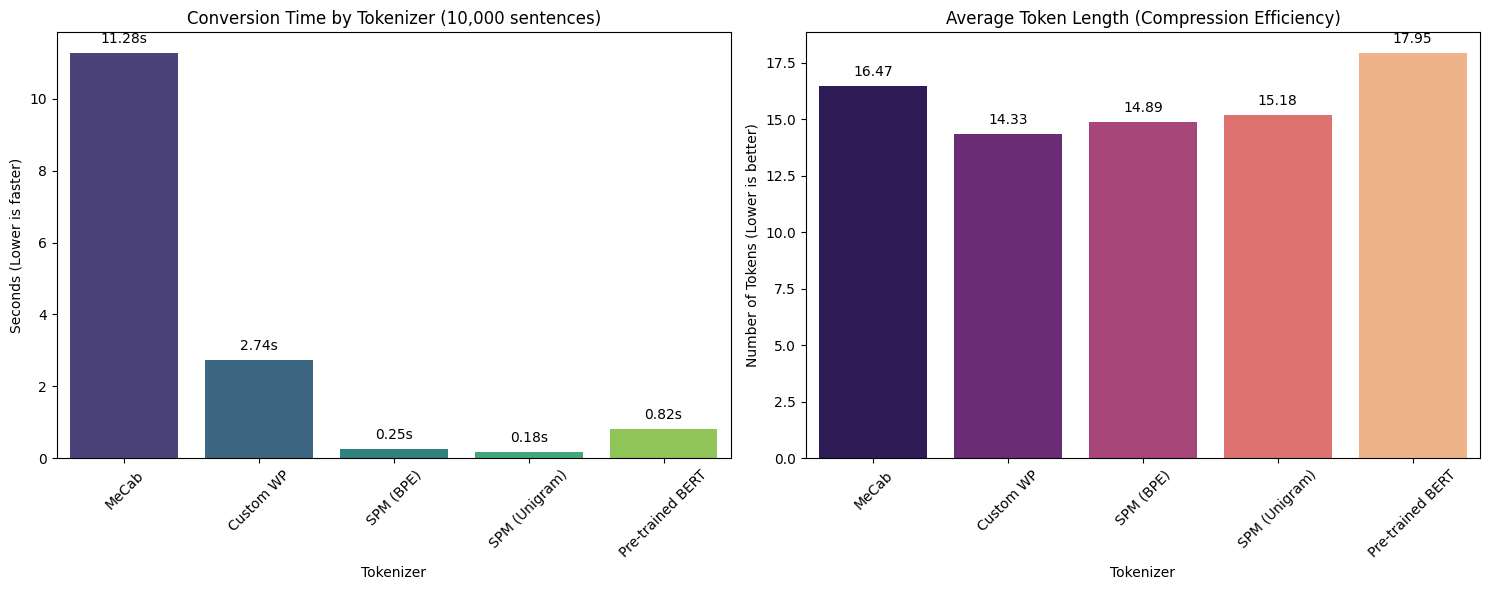

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화를 위한 데이터프레임 생성
viz_df = pd.DataFrame({
    'Tokenizer': ['MeCab', 'Custom WP', 'SPM (BPE)', 'SPM (Unigram)', 'Pre-trained BERT'],
    'Conversion Time (sec)': [mecab_time, hf_custom_time, spm_bpe_time, spm_uni_time, hf_bert_time],
    'Avg Token Length': [
        np.mean(mecab_lengths),
        np.mean(hf_custom_lengths),
        np.mean(spm_bpe_lengths),
        np.mean(spm_uni_lengths),
        np.mean(hf_bert_lengths)
    ]
})

# 그래프 그리기 설정
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 변환 속도 차트 (hue와 legend 설정 추가로 경고 제거)
sns.barplot(x='Tokenizer', y='Conversion Time (sec)', data=viz_df, ax=axes[0], palette='viridis', hue='Tokenizer', legend=False)
axes[0].set_title('Conversion Time by Tokenizer (10,000 sentences)')
axes[0].set_ylabel('Seconds (Lower is faster)')
axes[0].tick_params(axis='x', rotation=45)
# 막대 위에 수치 표시
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# 2. 평균 토큰 길이 차트 (hue와 legend 설정 추가로 경고 제거)
sns.barplot(x='Tokenizer', y='Avg Token Length', data=viz_df, ax=axes[1], palette='magma', hue='Tokenizer', legend=False)
axes[1].set_title('Average Token Length (Compression Efficiency)')
axes[1].set_ylabel('Number of Tokens (Lower is better)')
axes[1].tick_params(axis='x', rotation=45)
# 막대 위에 수치 표시
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

=== 토크나이저 학습 속도 측정 시작 (단어사전 크기: 8000) ===
[Custom WordPiece] 학습 완료: 8.76초
[SPM BPE] 학습 완료: 43.72초
[SPM Unigram] 학습 완료: 63.56초


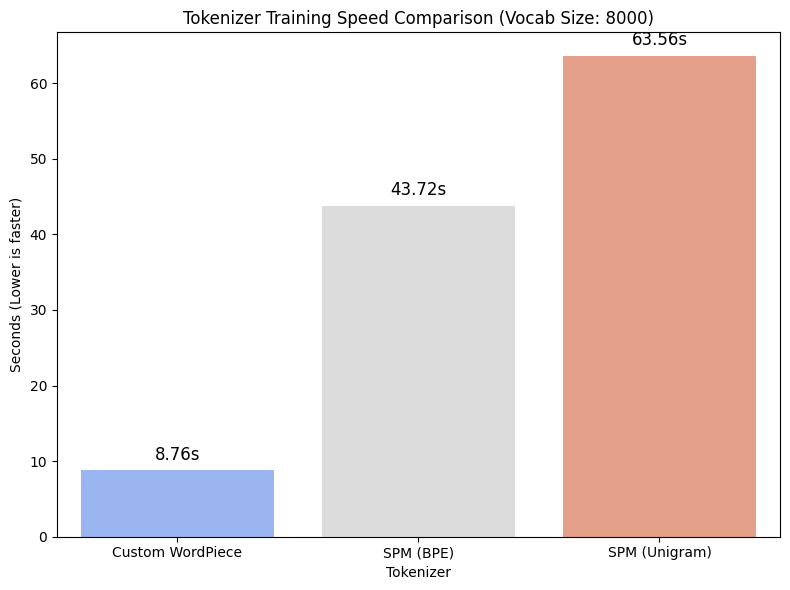

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tokenizers import BertWordPieceTokenizer
import sentencepiece as spm

# 1. 학습 데이터 준비 (전체 clean_document 사용)
texts = df['clean_document'].dropna().tolist()

# SPM 학습을 위한 텍스트 파일 저장 (벤치마크용 임시 파일)
with open('spm_benchmark_train.txt', 'w', encoding='utf-8') as f:
    for text in texts:
        f.write(str(text) + '\n')

print("=== 토크나이저 학습 속도 측정 시작 (단어사전 크기: 8000) ===")

# 2. Hugging Face Custom WordPiece 학습 시간 측정
custom_tokenizer_bench = BertWordPieceTokenizer(
    clean_text=True, handle_chinese_chars=True, strip_accents=False, lowercase=False
)
start_time = time.time()
custom_tokenizer_bench.train_from_iterator(texts, vocab_size=8000, min_frequency=2)
hf_train_time = time.time() - start_time
print(f"[Custom WordPiece] 학습 완료: {hf_train_time:.2f}초")

# 3. SentencePiece (BPE) 학습 시간 측정
start_time = time.time()
spm.SentencePieceTrainer.train(
    input='spm_benchmark_train.txt', model_prefix='bench_spm_bpe',
    vocab_size=8000, model_type='bpe', pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
spm_bpe_train_time = time.time() - start_time
print(f"[SPM BPE] 학습 완료: {spm_bpe_train_time:.2f}초")

# 4. SentencePiece (Unigram) 학습 시간 측정
start_time = time.time()
spm.SentencePieceTrainer.train(
    input='spm_benchmark_train.txt', model_prefix='bench_spm_uni',
    vocab_size=8000, model_type='unigram', pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
spm_uni_train_time = time.time() - start_time
print(f"[SPM Unigram] 학습 완료: {spm_uni_train_time:.2f}초")

# 5. 결과 시각화
train_time_df = pd.DataFrame({
    'Tokenizer': ['Custom WordPiece', 'SPM (BPE)', 'SPM (Unigram)'],
    'Training Time (sec)': [hf_train_time, spm_bpe_train_time, spm_uni_train_time]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Tokenizer', y='Training Time (sec)', data=train_time_df,
                 palette='coolwarm', hue='Tokenizer', legend=False)
plt.title('Tokenizer Training Speed Comparison (Vocab Size: 8000)')
plt.ylabel('Seconds (Lower is faster)')

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 리뷰

1. MeCab은 다른 토큰화 방식에 비해 속도와 정확도 면에서 많이 떨어지는 성능을 보임
- 단순히 사전을 기반으로 형태소 변환을 하기 때문에 의성어, 신조어, 오타에 취약한 모습을 보여줌
2. 허깅페이스의 pre-trained은 다른 모델에 비해 더 많은 토큰 수를 가짐
3. Sentence Piece는 방식에 따라 엄청난 차이를 보이지는 않아 보임
4. 상위 20개의 토큰은 대부분 조사/어미가 차지하는 모습을 보임
- 만약 이런 데이터로 감성 분석을 진행한다면 상위 토큰은 불용어 처리를 반드시 해야 할 것
5. SPM의 토큰 상위 20개 토큰 종류에는 큰 차이가 나지 않음
6.. 허깅페이스는 직접 학습 시킨 모델이 진짜, 정말, 너무 같은 부사를 더 잘 포착함

### 발전시킬 점

- 현재 데이터 전처리 과정에서 .를 전부 제거 시켜서 학습을 진행함
 - 마침표 부분에 문장이 끝난다는 표시를 남기고 전처리를 하면 더 좋은 모델이 나오지 않을까?
- 맞춤법 오류에 따른 이상치 발생, 맞춤법을 교정 후 데이터를 학습 시키면 더 좋은 모델이 나올 수 있을 것


## 데이터 전처리 다시 진행

In [ ]:
import re

def preprocessor_v2(text):
    if pd.isnull(text):
        return ""

    text = str(text)

    # 1. 문장 구분자 변환
    # 마침표, 물음표, 느낌표가 연속될 경우 하나의 줄바꿈(\n)으로 변경
    text = re.sub(r'[.?!]+', '\n', text)

    # 2. 특수문자 제거 (줄바꿈 \n은 보존)
    # 한글, 숫자, 공백(스페이스, 탭 등), 그리고 \n을 제외한 모든 문자 제거
    text = re.sub(r'[^가-힣0-9\s\n]', '', text)

    # 3. 공백 정제
    # 줄바꿈 기호를 제외한 연속된 공백을 하나로 줄임
    text = re.sub(r'[^\S\n]+', ' ', text)

    # 연속된 줄바꿈 기호를 하나로 줄이고, 양 끝 공백/줄바꿈 제거
    text = re.sub(r'\n+', '\n', text).strip()

    return text

# 새로운 전처리 적용
df['clean_document_v2'] = df['document'].apply(preprocessor_v2)

# 결과 확인 (특히 \n이 어떻게 들어갔는지 확인하기 위해 repr 사용)
print("=== 새로운 전처리 결과 (문장 구분 \\n 적용) ===")
for i in [0, 1, 3, 4, 11]:
    print(f"[원본 {i}] {df['document'].iloc[i]}")
    print(f"[수정 {i}] {repr(df['clean_document_v2'].iloc[i])}\n")

=== 새로운 전처리 결과 (문장 구분 \n 적용) ===
[원본 0] 아 더빙.. 진짜 짜증나네요 목소리
[수정 0] '아 더빙\n 진짜 짜증나네요 목소리'

[원본 1] 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
[수정 1] '흠\n포스터보고 초딩영화줄\n오버연기조차 가볍지 않구나'

[원본 3] 교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정
[수정 3] '교도소 이야기구먼 \n솔직히 재미는 없다\n평점 조정'

[원본 4] 사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다
[수정 4] '사이몬페그의 익살스런 연기가 돋보였던 영화\n스파이더맨에서 늙어보이기만 했던 커스틴 던스트가 너무나도 이뻐보였다'

[원본 11] 볼때마다 눈물나서 죽겠다90년대의 향수자극!!허진호는 감성절제멜로의 달인이다~
[수정 11] '볼때마다 눈물나서 죽겠다90년대의 향수자극\n허진호는 감성절제멜로의 달인이다'



In [ ]:
# 1. '\n'을 기준으로 텍스트를 분리하여 모든 문장을 개별 리스트 요소로 전개(Explode)
# 이렇게 하면 긴 리뷰 1개가 여러 개의 짧은 문장 데이터로 쪼개집니다.
sentences_v2 = df['clean_document_v2'].dropna().apply(lambda x: x.split('\n')).explode().tolist()

# 빈 문자열을 제거하고 양끝 공백 정리
sentences_v2 = [s.strip() for s in sentences_v2 if s.strip()]

print(f"원본 리뷰 개수: {len(df['clean_document_v2'].dropna())}개")
print(f"문장 단위로 분리된 데이터 개수: {len(sentences_v2)}개\n")

# 상위 5개 문장 확인
print("=== 분리된 문장 샘플 ===")
for i in range(10):
    print(f"[{i}] {sentences_v2[i]}")

원본 리뷰 개수: 150000개
문장 단위로 분리된 데이터 개수: 242149개

=== 분리된 문장 샘플 ===
[0] 아 더빙
[1] 진짜 짜증나네요 목소리
[2] 흠
[3] 포스터보고 초딩영화줄
[4] 오버연기조차 가볍지 않구나
[5] 너무재밓었다그래서보는것을추천한다
[6] 교도소 이야기구먼
[7] 솔직히 재미는 없다
[8] 평점 조정
[9] 사이몬페그의 익살스런 연기가 돋보였던 영화


In [ ]:
# ==========================================
# [1] Hugging Face WordPiece 학습 (V2 데이터)
# ==========================================
from tokenizers import BertWordPieceTokenizer
import time

print("--- 1. Hugging Face WordPiece (V2) 학습 시작 ---")
custom_tokenizer_v2 = BertWordPieceTokenizer(
    clean_text=True, handle_chinese_chars=True, strip_accents=False, lowercase=False
)

start_time = time.time()
custom_tokenizer_v2.train_from_iterator(
    sentences_v2, vocab_size=8000, min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
)
elapsed_time = time.time() - start_time

print(f"WordPiece 학습 완료! 단어사전 크기: {custom_tokenizer_v2.get_vocab_size()}")
print(f"학습에 걸린 시간: {elapsed_time:.2f}초\n")

--- 1. Hugging Face WordPiece (V2) 학습 시작 ---
WordPiece 학습 완료! 단어사전 크기: 8000
학습에 걸린 시간: 8.12초



In [ ]:
# ==========================================
# [2] SentencePiece BPE 학습 (V2 데이터)
# ==========================================
import sentencepiece as spm
import time

print("--- 2. SentencePiece BPE (V2) 학습 시작 ---")
# SPM은 텍스트 파일 입력이 필요하므로 V2 데이터를 파일로 먼저 저장합니다.
with open('spm_train_v2.txt', 'w', encoding='utf-8') as f:
    for text in sentences_v2:
        f.write(text + '\n')

start_time = time.time()
spm.SentencePieceTrainer.train(
    input='spm_train_v2.txt', model_prefix='spm_bpe_v2',
    vocab_size=8000, model_type='bpe', pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
elapsed_time = time.time() - start_time

print("BPE 학습 완료! 'spm_bpe_v2.model' 파일이 생성되었습니다.")
print(f"학습에 걸린 시간: {elapsed_time:.2f}초\n")

--- 2. SentencePiece BPE (V2) 학습 시작 ---
BPE 학습 완료! 'spm_bpe_v2.model' 파일이 생성되었습니다.
학습에 걸린 시간: 38.67초



In [ ]:
# ==========================================
# [3] SentencePiece Unigram 학습 (V2 데이터)
# ==========================================
import sentencepiece as spm
import time

print("--- 3. SentencePiece Unigram (V2) 학습 시작 ---")
start_time = time.time()
spm.SentencePieceTrainer.train(
    input='spm_train_v2.txt', model_prefix='spm_uni_v2',
    vocab_size=8000, model_type='unigram', pad_id=0, unk_id=1, bos_id=2, eos_id=3
)
elapsed_time = time.time() - start_time

print("Unigram 학습 완료! 'spm_uni_v2.model' 파일이 생성되었습니다.")
print(f"학습에 걸린 시간: {elapsed_time:.2f}초\n")

--- 3. SentencePiece Unigram (V2) 학습 시작 ---
Unigram 학습 완료! 'spm_uni_v2.model' 파일이 생성되었습니다.
학습에 걸린 시간: 58.40초



In [ ]:
import time
import numpy as np
import sentencepiece as spm

# 학습된 SentencePiece 모델 로드 (혹시 메모리에 없을 경우를 대비)
spm_bpe_v2 = spm.SentencePieceProcessor()
spm_bpe_v2.load('spm_bpe_v2.model')

spm_uni_v2 = spm.SentencePieceProcessor()
spm_uni_v2.load('spm_uni_v2.model')

# 벤치마크용 샘플 데이터 (문장 단위 분리된 데이터 중 1만개 추출)
sample_corpus_v2 = sentences_v2[:10000]

print("="*60)
print("[1] V2 토크나이저 변환 속도 및 평균 시퀀스 길이 벤치마크 (1만 개 문장 기준)")
print("="*60)

# 1. Custom WordPiece V2
start = time.time()
wp_v2_lengths = [len(custom_tokenizer_v2.encode(t).tokens) for t in sample_corpus_v2]
wp_v2_time = time.time() - start

# 2. SentencePiece BPE V2
start = time.time()
bpe_v2_lengths = [len(spm_bpe_v2.encode_as_pieces(t)) for t in sample_corpus_v2]
bpe_v2_time = time.time() - start

# 3. SentencePiece Unigram V2
start = time.time()
uni_v2_lengths = [len(spm_uni_v2.encode_as_pieces(t)) for t in sample_corpus_v2]
uni_v2_time = time.time() - start

print(f"[WordPiece V2] 변환 속도: {wp_v2_time:.4f}초 | 평균 토큰 수: {np.mean(wp_v2_lengths):.2f}개")
print(f"[SPM BPE V2] 변환 속도: {bpe_v2_time:.4f}초 | 평균 토큰 수: {np.mean(bpe_v2_lengths):.2f}개")
print(f"[SPM Unigram V2] 변환 속도: {uni_v2_time:.4f}초 | 평균 토큰 수: {np.mean(uni_v2_lengths):.2f}개")

print("\n" + "="*60)
print("[2] OOV 대응력 및 디코딩(원문 복원) 테스트 (V2)")
print("="*60)

# 문장 구분 기호(\n)와 OOV가 포함된 테스트 문장
test_sentences_v2 = [
    "진짜 넘모넘모 재미있따ㅋㅋㅋ\n강추!!",
    "가슴이 웅장해진다...\n띵작 인정합니다 OTL",
    "스토리 개연성 1도 없고 노잼임\n돈아까움"
]

for i, sentence in enumerate(test_sentences_v2, 1):
    print(f"\n[{i}] 원본 문장: {repr(sentence)}")

    tk_wp = custom_tokenizer_v2.encode(sentence).tokens
    tk_bpe = spm_bpe_v2.encode_as_pieces(sentence)
    tk_uni = spm_uni_v2.encode_as_pieces(sentence)

    print(f"  - [WordPiece V2] 토큰: {tk_wp}")
    print(f"  - [SPM BPE V2]   토큰: {tk_bpe}")
    print(f"  - [SPM Uni V2]   토큰: {tk_uni}")

    dec_wp = custom_tokenizer_v2.decode(custom_tokenizer_v2.encode(sentence).ids)
    dec_bpe = spm_bpe_v2.decode_pieces(tk_bpe)
    dec_uni = spm_uni_v2.decode_pieces(tk_uni)

    print(f"  => 디코딩 비교:")
    print(f"     WordPiece V2 : {repr(dec_wp)}")
    print(f"     SPM BPE V2   : {repr(dec_bpe)}")
    print(f"     SPM Uni V2   : {repr(dec_uni)}")


[1] V2 토크나이저 변환 속도 및 평균 시퀀스 길이 벤치마크 (1만 개 문장 기준)
[WordPiece V2] 변환 속도: 0.3249초 | 평균 토큰 수: 8.66개
[SPM BPE V2] 변환 속도: 0.1822초 | 평균 토큰 수: 9.00개
[SPM Unigram V2] 변환 속도: 0.1225초 | 평균 토큰 수: 9.17개

[2] OOV 대응력 및 디코딩(원문 복원) 테스트 (V2)

[1] 원본 문장: '진짜 넘모넘모 재미있따ㅋㅋㅋ\n강추!!'
  - [WordPiece V2] 토큰: ['진짜', '넘', '##모', '##넘', '##모', '[UNK]', '강추', '[UNK]', '[UNK]']
  - [SPM BPE V2]   토큰: ['▁진짜', '▁넘', '모', '넘', '모', '▁재미있', '따', 'ᄏᄏᄏ', '▁강추', '!!']
  - [SPM Uni V2]   토큰: ['▁진짜', '▁넘', '모', '넘', '모', '▁재미있', '따', 'ᄏᄏᄏ', '▁강추', '!!']
  => 디코딩 비교:
     WordPiece V2 : '진짜 넘모넘모 강추'
     SPM BPE V2   : '진짜 넘모넘모 재미있따ᄏᄏᄏ 강추!!'
     SPM Uni V2   : '진짜 넘모넘모 재미있따ᄏᄏᄏ 강추!!'

[2] 원본 문장: '가슴이 웅장해진다...\n띵작 인정합니다 OTL'
  - [WordPiece V2] 토큰: ['가슴이', '웅', '##장', '##해진다', '[UNK]', '[UNK]', '[UNK]', '[UNK]', '인정', '##합니다', '[UNK]']
  - [SPM BPE V2]   토큰: ['▁가슴이', '▁웅', '장', '해진다', '...', '▁', '띵', '작', '▁인정', '합니다', '▁', 'OTL']
  - [SPM Uni V2]   토큰: ['▁가슴이', '▁웅장', '해진다', '...', '▁', '띵', '작', '▁인정', '합니다', '▁', 'OTL']
  =

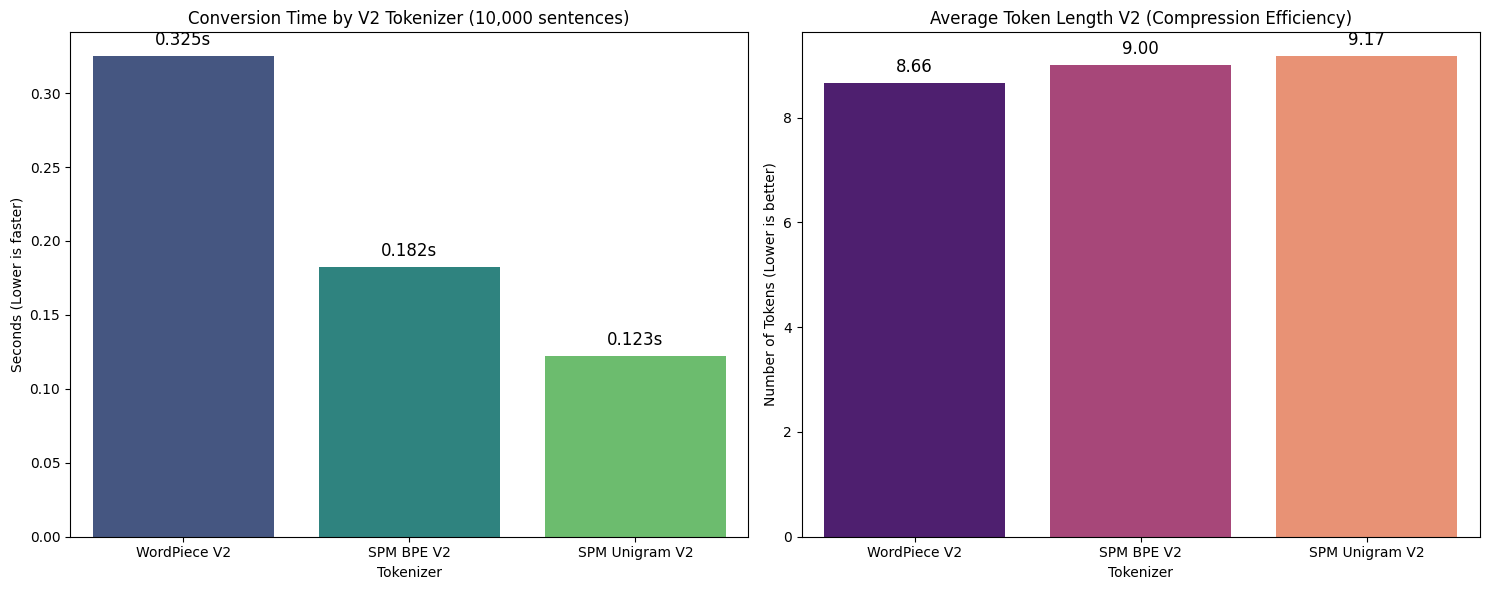

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화를 위한 데이터프레임 생성
viz_df_v2 = pd.DataFrame({
    'Tokenizer': ['WordPiece V2', 'SPM BPE V2', 'SPM Unigram V2'],
    'Conversion Time (sec)': [wp_v2_time, bpe_v2_time, uni_v2_time],
    'Avg Token Length': [np.mean(wp_v2_lengths), np.mean(bpe_v2_lengths), np.mean(uni_v2_lengths)]
})

# 그래프 그리기 설정
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 변환 속도 차트
sns.barplot(x='Tokenizer', y='Conversion Time (sec)', data=viz_df_v2, ax=axes[0], palette='viridis', hue='Tokenizer', legend=False)
axes[0].set_title('Conversion Time by V2 Tokenizer (10,000 sentences)')
axes[0].set_ylabel('Seconds (Lower is faster)')
# 막대 위에 수치 표시
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}s", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# 2. 평균 토큰 길이 차트
sns.barplot(x='Tokenizer', y='Avg Token Length', data=viz_df_v2, ax=axes[1], palette='magma', hue='Tokenizer', legend=False)
axes[1].set_title('Average Token Length V2 (Compression Efficiency)')
axes[1].set_ylabel('Number of Tokens (Lower is better)')
# 막대 위에 수치 표시
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from collections import Counter
import itertools

print("V2 전체 데이터(약 24만 개 문장)에 대한 토큰화 및 빈도수 계산 중... (잠시만 기다려주세요)")

# 1. WordPiece V2 토큰화 및 빈도 계산
wp_v2_tokens = list(itertools.chain.from_iterable([custom_tokenizer_v2.encode(t).tokens for t in sentences_v2]))
wp_v2_counts = Counter(wp_v2_tokens)
top20_wp_v2 = [token for token, freq in wp_v2_counts.most_common(20)]

# 2. SPM BPE V2 토큰화 및 빈도 계산
bpe_v2_tokens = list(itertools.chain.from_iterable([spm_bpe_v2.encode_as_pieces(t) for t in sentences_v2]))
bpe_v2_counts = Counter(bpe_v2_tokens)
top20_bpe_v2 = [token for token, freq in bpe_v2_counts.most_common(20)]

# 3. SPM Unigram V2 토큰화 및 빈도 계산
uni_v2_tokens = list(itertools.chain.from_iterable([spm_uni_v2.encode_as_pieces(t) for t in sentences_v2]))
uni_v2_counts = Counter(uni_v2_tokens)
top20_uni_v2 = [token for token, freq in uni_v2_counts.most_common(20)]

# 4. 요약 데이터프레임 생성
summary_df_v2 = pd.DataFrame({
    'Rank': range(1, 21),
    'WordPiece_V2': top20_wp_v2,
    'SPM_BPE_V2': top20_bpe_v2,
    'SPM_Unigram_V2': top20_uni_v2
})
summary_df_v2.set_index('Rank', inplace=True)

print("=== V2 모델 전체 데이터 토큰 빈도수 Top 20 ===")
display(summary_df_v2)


V2 전체 데이터(약 24만 개 문장)에 대한 토큰화 및 빈도수 계산 중... (잠시만 기다려주세요)
=== V2 모델 전체 데이터 토큰 빈도수 Top 20 ===


,WordPiece_V2,SPM_BPE_V2,SPM_Unigram_V2
Rank,,,
1,영화,▁영화,▁
2,[UNK],이,이
3,##이,의,▁영화
4,##도,도,의
5,##의,▁,도
6,##는,을,가
7,##을,에,는
8,##가,은,을
9,##에,▁너무,고


##  전처리 변화 후 토크나이저 종합 비교 리뷰

### 1. 변환 속도 및 압축 효율 (Inference & Compression)
* 변환 속도: SPM Unigram > SPM BPE > WordPiece
  * 학습 속도는 WordPiece가 압도적으로 빠르지만, 추론(텍스트 $\rightarrow$ 토큰 변환) 속도는 SentencePiece 계열이 내부 C++ 최적화로 인해 훨씬 빠름
* **압축 효율 (짧은 토큰 수 순):** WordPiece > SPM BPE > SPM Unigram
  * WordPiece가 가장 적은 수의 토큰으로 문장을 표현
  . 이는 모델의 시퀀스 길이를 줄여주어 Transformer 기반 언어 모델의 연산 효율성을 높이는 데 유리

### 2. OOV(미등록 단어) 대응 및 디코딩 복원력
* **WordPiece:** 사전에 없는 이모티콘(`ㅋㅋㅋ`, `OTL` 등)이나 특수 문자를 만나면 모두 `[UNK]` 처리. 이로 인해 디코딩 시 원문 정보가 영구적으로 유실되는 단점이 존재
* **SentencePiece (BPE/Unigram):** 사전에 없는 글자라도 바이트(Byte) 레벨 등 하위 단위로 보존(Fallback)하여 쪼갬. 덕분에 디코딩 시 **원문을 100% 완벽하게 복원**할 수 있어, 신조어/이모티콘이 많은 노이즈 데이터에 매우 강함.

### 최종 결론 및 활용 방안
* 모델의 **입력 길이 최소화 및 연산 속도**가 최우선이라면 **WordPiece**를 선택
* 띄어쓰기 정보 완벽 보존, **신조어/오타에 대한 강건함**, 그리고 빠른 추론 속도가 필요하다면 **SentencePiece** 방식이 더 적합